### Basmati Rice Seed Classification

In [1]:
import torch
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import copy
import random
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def get_data_loaders(data_dir, batch_size=32): 
    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(), # Seeds can be in any orientation
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        'val': transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
    }
    
    # Loading datasets
    image_datasets = {
        'train': datasets.ImageFolder(f"{data_dir}\\train", data_transforms['train']),
        'val': datasets.ImageFolder(f"{data_dir}\\test_val", data_transforms['val']),
        'test': datasets.ImageFolder(f"{data_dir}\\test", data_transforms['val'])
    }
    
    # Creating dataloaders with dynamic shuffling
    dataloaders = {
        x: DataLoader(
            image_datasets[x], 
            batch_size=batch_size,   
            shuffle=(x == 'train'),  
            num_workers=2,           
            pin_memory=True          
        ) 
        for x in ['train', 'val', 'test']
    }
    
    return dataloaders, image_datasets['train'].class_to_idx

In [2]:
def visualize_seed_varieties(dataloader, class_map, num_images=6):
    print("\nVisualizing a batch of seed varieties...")
    # Get a batch of training data
    inputs, classes = next(iter(dataloader))
    
    def imshow(inp, title=None):
        inp = inp.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        inp = std * inp + mean
        inp = np.clip(inp, 0, 1)
        plt.imshow(inp)
        if title is not None:
            plt.title(title, fontsize=10)
        plt.axis('off')

    # Reversing class_map to get names from indices
    idx_to_class = {v: k for k, v in class_map.items()}
    
    # Plotting the images
    plt.figure(figsize=(15, 6))
    for i in range(min(num_images, inputs.size(0))):
        plt.subplot(2, int(np.ceil(num_images/2)), i + 1)
        imshow(inputs[i], title=idx_to_class[classes[i].item()])
        
    plt.suptitle('Sample Rice Seed Varieties (Preprocessed)', fontsize=16)
    plt.tight_layout()
    plt.savefig('seed_varieties_sample.png', dpi=150)
    print("Saved sample visualization as 'seed_varieties_sample.png'.")
    plt.show()

In [3]:
def train_and_validate_model(model, dataloaders, criterion, optimizer, device, num_epochs=10):
    # Dictionaries to store metrics for plotting later
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        #print(f"Epoch {epoch+1}/{num_epochs}")
        #print('-' * 10)
        
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0.0
        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data)
            
        avg_train_loss = train_loss / len(dataloaders['train'].dataset)
        history['train_loss'].append(avg_train_loss)
        train_acc = train_correct.double() / len(dataloaders['train'].dataset)
        
        # validation
        model.eval()
        val_loss = 0.0
        correct = 0
        
        with torch.no_grad():
            for inputs, labels in dataloaders['val']:
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += torch.sum(preds == labels.data)
                
        avg_val_loss = val_loss / len(dataloaders['val'].dataset)
        val_acc = correct.double() / len(dataloaders['val'].dataset)


        history['train_acc'].append(train_acc.item())
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc.item()) # .item() extracts float from tensor
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} |Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        # Save best model
        #if val_acc > best_acc:
        if avg_val_loss < best_val_loss:
            best_acc = val_acc
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_basmati_model.pth')
            print(f"  -> Saved new best model! (Val Loss: {best_val_loss:.4f})")
            
    print(f"\nTraining complete. Validation Accuracy: {best_acc:.4f} and Validation Loss: {best_val_loss:.4f}")
    
    # Load best model weights before returning
    model.load_state_dict(best_model_wts)
    return model, history

In [4]:
def plot_training_history(history):
    print("\nGenerating training history plots...")
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('training_history_plots_resnet.png', dpi=300)
    print("Saved training history plots as 'training_history_plots_resnet.png'.")
    plt.show()

In [5]:
def evaluate_on_test(model, test_loader, class_names, device):
    print("\nEvaluating on Test Set...")
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names, 
                cbar=False,
                linewidths=0.5,
                linecolor='gray')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix - Basmati Rice Classification')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('confusion_matrix_resnet.png')
    print("Confusion matrix saved as 'confusion_matrix_resnet.png'")

=== Basmati Rice Seed Classification ===


Please enter the path to the dataset directory (e.g., D:\Project\iRSVPred_data):  D:\Project\iRSVPred_data



Using device: cuda
Loaded 11 classes: {'1121': 0, '1509': 1, '1637': 2, '1718': 3, '1728': 4, 'BAS_370': 5, 'CSR_30': 6, 'DHBT_3': 7, 'PB1': 8, 'PB_6': 9, 'Unknown': 10}


Visualizing a batch of seed varieties...
Saved sample visualization as 'seed_varieties_sample.png'.


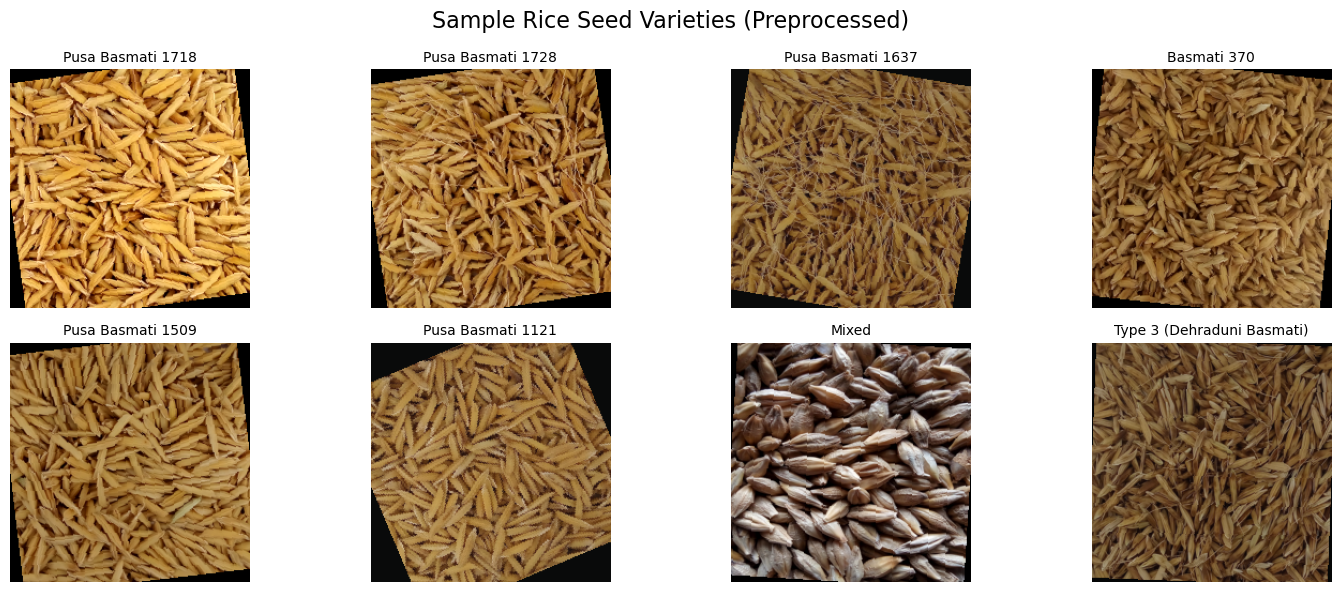

Epoch 1/15 | Train Loss: 2.1455 |Train Acc: 0.3072 | Val Loss: 1.7995 | Val Acc: 0.4860
  -> Saved new best model! (Val Loss: 1.7995)
Epoch 2/15 | Train Loss: 1.4877 |Train Acc: 0.5997 | Val Loss: 0.9937 | Val Acc: 0.7259
  -> Saved new best model! (Val Loss: 0.9937)
Epoch 3/15 | Train Loss: 0.7779 |Train Acc: 0.7847 | Val Loss: 0.4571 | Val Acc: 0.8692
  -> Saved new best model! (Val Loss: 0.4571)
Epoch 4/15 | Train Loss: 0.4108 |Train Acc: 0.8793 | Val Loss: 0.1622 | Val Acc: 0.9564
  -> Saved new best model! (Val Loss: 0.1622)
Epoch 5/15 | Train Loss: 0.2389 |Train Acc: 0.9280 | Val Loss: 0.2012 | Val Acc: 0.9159
Epoch 6/15 | Train Loss: 0.1671 |Train Acc: 0.9525 | Val Loss: 0.1680 | Val Acc: 0.9221
Epoch 7/15 | Train Loss: 0.1373 |Train Acc: 0.9560 | Val Loss: 0.2639 | Val Acc: 0.8847
Epoch 8/15 | Train Loss: 0.1246 |Train Acc: 0.9618 | Val Loss: 0.2473 | Val Acc: 0.9034
Epoch 9/15 | Train Loss: 0.1023 |Train Acc: 0.9669 | Val Loss: 0.0894 | Val Acc: 0.9657
  -> Saved new best mode

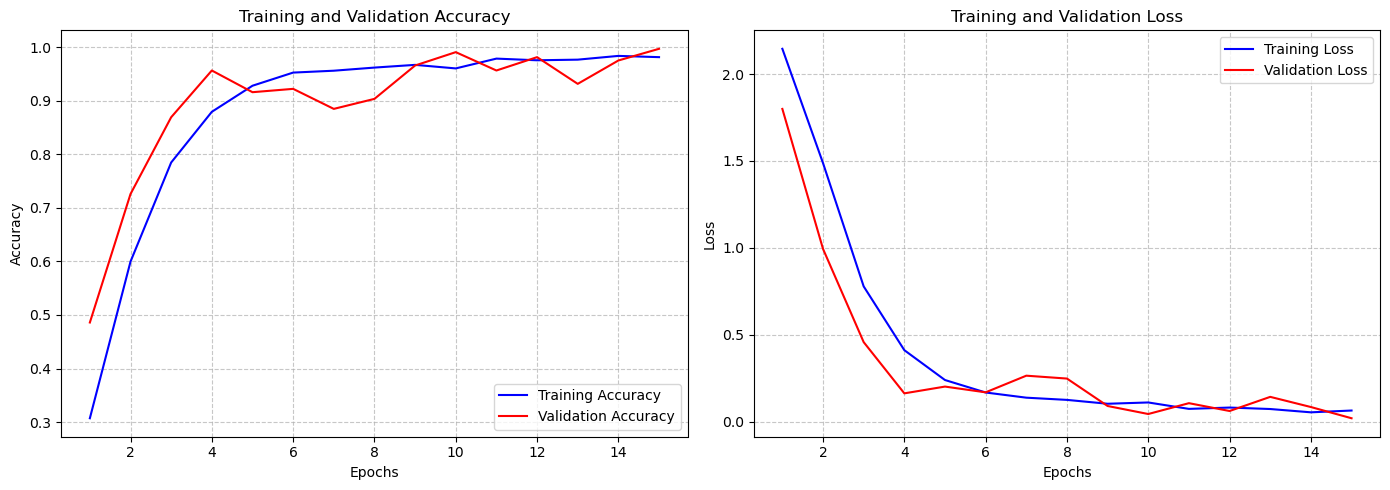


Evaluating best model on Test Set...

Evaluating on Test Set...

Classification Report:
                            precision    recall  f1-score   support

         Pusa Basmati 1121       1.00      1.00      1.00        25
         Pusa Basmati 1509       1.00      1.00      1.00        25
         Pusa Basmati 1637       0.96      1.00      0.98        25
         Pusa Basmati 1718       0.78      1.00      0.88        25
         Pusa Basmati 1728       1.00      0.72      0.84        25
               Basmati 370       1.00      1.00      1.00        25
            Basmati CSR 30       1.00      1.00      1.00        25
Type 3 (Dehraduni Basmati)       1.00      1.00      1.00        25
            Pusa Basmati 1       0.96      1.00      0.98        25
            Pusa Basmati 6       1.00      0.92      0.96        25
                     Mixed       1.00      1.00      1.00        71

                  accuracy                           0.97       321
                 macro av

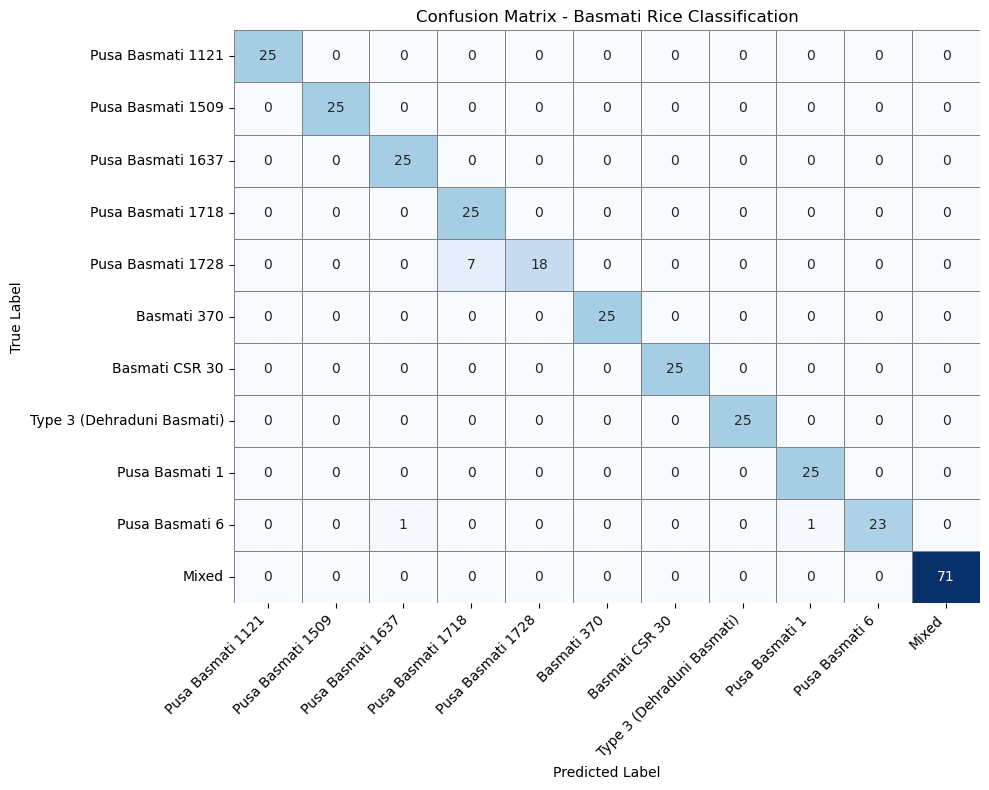

In [6]:
if __name__ == '__main__':
    #Setting seeds for reproducibility
    seed = 5
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    #torch.backends.cudnn.deterministic = True
    #torch.backends.cudnn.benchmark = False
    
    # Input dataset path
    print("=== Basmati Rice Seed Classification ===")
    DATA_PATH = input(r"Please enter the path to the dataset directory (e.g., D:\Project\iRSVPred_data): ").strip()
    
    # Check if folder exists
    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError(f"The directory '{DATA_PATH}' does not exist. Please check the path and try running the script again.")

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nUsing device: {DEVICE}")
    
    #get Pretty class names and visualize a batch of seed varieties
    folder_to_name_map = {       
        "1121": "Pusa Basmati 1121",
        "1509": "Pusa Basmati 1509",
        "1637": "Pusa Basmati 1637",
        "1728": "Pusa Basmati 1728",
        "1718": "Pusa Basmati 1718",
        "BAS_370": "Basmati 370",
        "CSR_30": "Basmati CSR 30",
        "DHBT_3": "Type 3 (Dehraduni Basmati)",
        "PB_6": "Pusa Basmati 6",
        "PB1": "Pusa Basmati 1",  
        "Unknown": "Mixed"
    }
    # Initialize
    loaders, class_map = get_data_loaders(DATA_PATH)
    print(f"Loaded {len(class_map)} classes: {class_map}\n")
    pytorch_folders_sorted = list(class_map.keys())
    try:
        pretty_class_names = [folder_to_name_map[folder] for folder in pytorch_folders_sorted]
    except KeyError as e:
        print(f"\n[ERROR] PyTorch found a folder named {e} but it's not in your dictionary!")
        print(f"Folders PyTorch found: {pytorch_folders_sorted}")

    #Visualize Data Preprocessing 
    visualize_seed_varieties(loaders['train'], dict(zip(pretty_class_names, class_map.values())), num_images=8)

    model = timm.create_model('seresnet50', pretrained=True, num_classes=len(class_map)).to(DEVICE)
    
    # Adam OPtimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) 
    criterion = torch.nn.CrossEntropyLoss()

    # Start Training (Patience set to 5 here)
    model,results_history = train_and_validate_model(model, loaders, criterion, optimizer, DEVICE, num_epochs=15)
    # Plot Training History
    plot_training_history(results_history)

    # Evaluate on Test Set
    class_names = list(class_map.keys())
    print("\nEvaluating best model on Test Set...")
   # get_predictions(model, loaders['test'], pretty_class_names, DEVICE)
    evaluate_on_test(model, loaders['test'], pretty_class_names, DEVICE)